# Fraud Detection using GANs
## BiGAN and AnoGAN on Credit Card Fraud Dataset

**Course:** Fraud Analytics  
**Approach:** Anomaly detection using generative adversarial networks  
**Dataset:** Credit Card Fraud Detection (Kaggle) — 284,807 transactions, ~0.17% fraud

### Overview
Both BiGAN and AnoGAN treat fraud detection as **one-class / anomaly detection**:  
- Train **only on normal (Class=0)** transactions  
- At inference, transactions that the generator cannot reconstruct well → flagged as fraud  

### Architecture Summary
| Model | Key Idea | Score |
|-------|---------|-------|
| **AnoGAN** | Generator + Discriminator; anomaly = high reconstruction + feature loss | Reconstruction + feature match |
| **BiGAN** | Adds Encoder; anomaly = joint discriminator score on (x, E(x)) pair | Discriminator score on real vs encoded |


## 1. Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve,
    roc_curve, confusion_matrix, classification_report, f1_score
)
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')

Using device: cpu
PyTorch version: 2.11.0+cu130


## 2. Data Loading and Exploratory Analysis

In [5]:
# ---------------------------------------------------------------
# Load Data
# The archive contains creditcard.csv — update path if needed
# ---------------------------------------------------------------
!pip install gdown
import pandas as pd
import gdown
import os

def load_data():
    if os.path.exists('/kaggle/input'):
        return pd.read_csv('/kaggle/input/credit-card/creditcard.csv')

    if os.path.exists('creditcard.csv'):
        return pd.read_csv('creditcard.csv')

    url = "https://drive.google.com/uc?id=1RDXwSTCtJ6CAdEmLq_92TIuF5QY8n5M_"
    gdown.download(url, 'creditcard.csv', quiet=False)

    return pd.read_csv('creditcard.csv')

df = load_data()
print('Dataset shape:', df.shape)
print('\nClass distribution:')
print(df['Class'].value_counts())
print(f'\nFraud rate: {df["Class"].mean()*100:.4f}%')
print('\nMissing values:', df.isnull().sum().sum())
df.head()

Dataset shape: (284807, 31)

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud rate: 0.1727%

Missing values: 0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


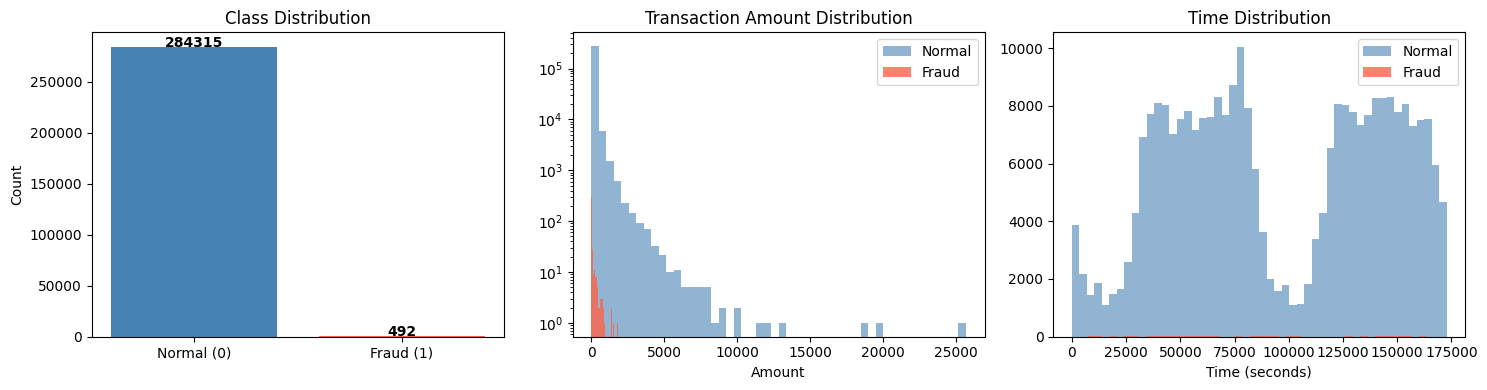

EDA plot saved.


: 

In [ ]:
# ---------------------------------------------------------------
# EDA Visualizations
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Class distribution
counts = df['Class'].value_counts()
axes[0].bar(['Normal (0)', 'Fraud (1)'], counts.values, color=['steelblue', 'tomato'])
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, str(v), ha='center', fontweight='bold')

# Transaction Amount distribution by class
axes[1].hist(df[df['Class']==0]['Amount'], bins=50, alpha=0.6, label='Normal', color='steelblue')
axes[1].hist(df[df['Class']==1]['Amount'], bins=50, alpha=0.8, label='Fraud', color='tomato')
axes[1].set_title('Transaction Amount Distribution')
axes[1].set_xlabel('Amount')
axes[1].set_yscale('log')
axes[1].legend()

# Time distribution
axes[2].hist(df[df['Class']==0]['Time'], bins=50, alpha=0.6, label='Normal', color='steelblue')
axes[2].hist(df[df['Class']==1]['Time'], bins=50, alpha=0.8, label='Fraud', color='tomato')
axes[2].set_title('Time Distribution')
axes[2].set_xlabel('Time (seconds)')
axes[2].legend()

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA plot saved.')

## 3. Preprocessing

In [ ]:
# ---------------------------------------------------------------
# Feature Engineering
# V1–V28 are already PCA-transformed; scale Time and Amount
# ---------------------------------------------------------------
scaler = StandardScaler()
df['scaled_Amount'] = scaler.fit_transform(df[['Amount']])
df['scaled_Time']   = scaler.fit_transform(df[['Time']])

features = [f'V{i}' for i in range(1, 29)] + ['scaled_Amount', 'scaled_Time']
X = df[features].values.astype(np.float32)
y = df['Class'].values

INPUT_DIM = X.shape[1]
print(f'Input dimension: {INPUT_DIM}')

# ---------------------------------------------------------------
# Split: train on NORMAL only; test on full data
# ---------------------------------------------------------------
X_normal = X[y == 0]
X_fraud  = X[y == 1]

# Hold out 20% of normal for evaluation
X_train, X_val_normal = train_test_split(X_normal, test_size=0.2, random_state=SEED)

# Test set: all fraud + held-out normal
X_test = np.vstack([X_val_normal, X_fraud])
y_test = np.hstack([np.zeros(len(X_val_normal)), np.ones(len(X_fraud))])

print(f'Train (normal): {X_train.shape}')
print(f'Test total:     {X_test.shape}  |  fraud: {y_test.sum():.0f}')

Input dimension: 30
Train (normal): (227452, 30)
Test total:     (57355, 30)  |  fraud: 492


: 

In [ ]:
# ---------------------------------------------------------------
# DataLoaders
# ---------------------------------------------------------------
BATCH_SIZE = 256

train_tensor = torch.FloatTensor(X_train)
train_loader = DataLoader(
    TensorDataset(train_tensor),
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True
)

print(f'Train batches: {len(train_loader)}')

Train batches: 888


: 

---
## 4. AnoGAN — Anomaly Detection with GAN

**Reference:** Schlegl et al. (2017) *Unsupervised Anomaly Detection with Generative Adversarial Networks*

**Key idea:**
1. Train a standard DCGAN on normal data
2. At test time, for each query $x$, **optimize** a latent vector $z$ to minimize:
   $$\mathcal{A}(x) = (1-\lambda)\|x - G(z)\|_1 + \lambda \|f(x) - f(G(z))\|_2$$
   where $f(\cdot)$ is an intermediate discriminator feature map
3. The residual score after optimization is the anomaly score

In [ ]:
# ---------------------------------------------------------------
# AnoGAN Architecture
# ---------------------------------------------------------------
LATENT_DIM = 32

class AnoGAN_Generator(nn.Module):
    """Maps latent z -> synthetic transaction features"""
    def __init__(self, latent_dim=LATENT_DIM, output_dim=INPUT_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, output_dim),
            nn.Tanh()
        )
    def forward(self, z):
        return self.net(z)


class AnoGAN_Discriminator(nn.Module):
    """Classifies real vs generated; exposes intermediate features for AnoGAN loss"""
    def __init__(self, input_dim=INPUT_DIM):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),
        )
        self.classifier = nn.Sequential(
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        features = self.feature_extractor(x)
        validity = self.classifier(features)
        return validity

    def get_features(self, x):
        return self.feature_extractor(x)


anogan_G = AnoGAN_Generator().to(DEVICE)
anogan_D = AnoGAN_Discriminator().to(DEVICE)

print('Generator params:', sum(p.numel() for p in anogan_G.parameters()))
print('Discriminator params:', sum(p.numel() for p in anogan_D.parameters()))

Generator params: 52062
Discriminator params: 49153


: 

Training AnoGAN...
  Epoch [ 20/100] D_loss: 0.0767  G_loss: 5.2902
  Epoch [ 40/100] D_loss: 0.0408  G_loss: 6.4204
  Epoch [ 60/100] D_loss: 0.0328  G_loss: 6.8570
  Epoch [ 80/100] D_loss: 0.0342  G_loss: 6.6761
  Epoch [100/100] D_loss: 0.0373  G_loss: 6.5670
AnoGAN training complete.


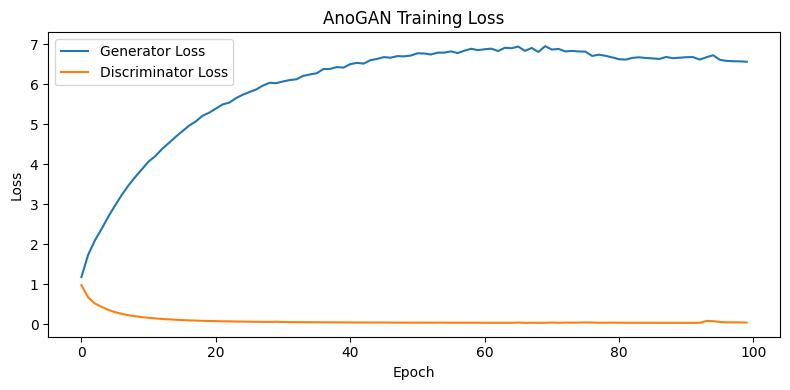

: 

In [ ]:
# ---------------------------------------------------------------
# AnoGAN Training
# ---------------------------------------------------------------
ANOGAN_EPOCHS = 100
LR = 0.0002
criterion = nn.BCELoss()

opt_G = optim.Adam(anogan_G.parameters(), lr=LR, betas=(0.5, 0.999))
opt_D = optim.Adam(anogan_D.parameters(), lr=LR, betas=(0.5, 0.999))

anogan_g_losses, anogan_d_losses = [], []

print('Training AnoGAN...')
for epoch in range(ANOGAN_EPOCHS):
    g_loss_epoch, d_loss_epoch = 0, 0

    for (real_batch,) in train_loader:
        real_batch = real_batch.to(DEVICE)
        bsz = real_batch.size(0)

        real_labels = torch.ones(bsz, 1).to(DEVICE)
        fake_labels = torch.zeros(bsz, 1).to(DEVICE)

        # ── Train Discriminator ──
        opt_D.zero_grad()
        z = torch.randn(bsz, LATENT_DIM).to(DEVICE)
        fake = anogan_G(z).detach()
        d_loss = criterion(anogan_D(real_batch), real_labels) + \
                 criterion(anogan_D(fake), fake_labels)
        d_loss.backward()
        opt_D.step()

        # ── Train Generator ──
        opt_G.zero_grad()
        z = torch.randn(bsz, LATENT_DIM).to(DEVICE)
        fake = anogan_G(z)
        g_loss = criterion(anogan_D(fake), real_labels)
        g_loss.backward()
        opt_G.step()

        g_loss_epoch += g_loss.item()
        d_loss_epoch += d_loss.item()

    n = len(train_loader)
    anogan_g_losses.append(g_loss_epoch / n)
    anogan_d_losses.append(d_loss_epoch / n)

    if (epoch + 1) % 20 == 0:
        print(f'  Epoch [{epoch+1:3d}/{ANOGAN_EPOCHS}] '
              f'D_loss: {anogan_d_losses[-1]:.4f}  G_loss: {anogan_g_losses[-1]:.4f}')

print('AnoGAN training complete.')

# Plot training curves
plt.figure(figsize=(8, 4))
plt.plot(anogan_g_losses, label='Generator Loss')
plt.plot(anogan_d_losses, label='Discriminator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('AnoGAN Training Loss')
plt.legend()
plt.tight_layout()
plt.savefig('anogan_training_loss.png', dpi=150)
plt.show()

In [ ]:
# ---------------------------------------------------------------
# AnoGAN Inference: Optimize z for each test sample
# Anomaly score = (1-λ)*reconstruction_loss + λ*feature_match_loss
# ---------------------------------------------------------------
LAMBDA      = 0.1      # weight for feature-match loss
N_ITER      = 500      # latent optimization steps
LR_INF      = 0.01
BATCH_INF   = 512      # samples per inference batch

anogan_G.eval()
anogan_D.eval()

def anogan_score(X_query, lambda_=LAMBDA, n_iter=N_ITER, lr=LR_INF, batch=BATCH_INF):
    """
    Compute AnoGAN anomaly scores for a batch of samples.
    Returns numpy array of anomaly scores (higher = more anomalous).
    """
    scores = []
    for start in range(0, len(X_query), batch):
        x_np = X_query[start:start+batch]
        x = torch.FloatTensor(x_np).to(DEVICE)

        # Initialize random z, make it trainable
        z = torch.randn(len(x_np), LATENT_DIM, requires_grad=True, device=DEVICE)
        opt_z = optim.Adam([z], lr=lr)

        for _ in range(n_iter):
            opt_z.zero_grad()
            x_hat = anogan_G(z)
            # Reconstruction loss
            rec_loss  = torch.mean(torch.abs(x - x_hat), dim=1)
            # Feature-match loss
            feat_real = anogan_D.get_features(x).detach()
            feat_fake = anogan_D.get_features(x_hat)
            feat_loss = torch.mean((feat_real - feat_fake) ** 2, dim=1)
            loss = ((1 - lambda_) * rec_loss + lambda_ * feat_loss).mean()
            loss.backward()
            opt_z.step()

        # Final anomaly score
        with torch.no_grad():
            x_hat = anogan_G(z)
            rec  = torch.mean(torch.abs(x - x_hat), dim=1)
            ff   = anogan_D.get_features(x)
            fg   = anogan_D.get_features(x_hat)
            feat = torch.mean((ff - fg) ** 2, dim=1)
            s = (1 - lambda_) * rec + lambda_ * feat
            scores.append(s.cpu().numpy())

        if start % (BATCH_INF * 5) == 0:
            print(f'  Processed {start+len(x_np)}/{len(X_query)} samples...')

    return np.concatenate(scores)

print('Computing AnoGAN anomaly scores on test set (this may take a few minutes)...')
anogan_scores = anogan_score(X_test)
print(f'Score range: [{anogan_scores.min():.4f}, {anogan_scores.max():.4f}]')

Computing AnoGAN anomaly scores on test set (this may take a few minutes)...
  Processed 512/57355 samples...
  Processed 3072/57355 samples...
  Processed 5632/57355 samples...
  Processed 8192/57355 samples...
  Processed 10752/57355 samples...
  Processed 13312/57355 samples...
  Processed 15872/57355 samples...
  Processed 18432/57355 samples...
  Processed 20992/57355 samples...
  Processed 23552/57355 samples...
  Processed 26112/57355 samples...
  Processed 28672/57355 samples...
  Processed 31232/57355 samples...
  Processed 33792/57355 samples...
  Processed 36352/57355 samples...
  Processed 38912/57355 samples...
  Processed 41472/57355 samples...
  Processed 44032/57355 samples...
  Processed 46592/57355 samples...
  Processed 49152/57355 samples...
  Processed 51712/57355 samples...
  Processed 54272/57355 samples...
  Processed 56832/57355 samples...
Score range: [0.0125, 8085.1880]


: 

In [ ]:
# ---------------------------------------------------------------
# AnoGAN Evaluation
# ---------------------------------------------------------------
anogan_auroc = roc_auc_score(y_test, anogan_scores)
anogan_auprc = average_precision_score(y_test, anogan_scores)

# Best F1 threshold
precisions, recalls, thresholds = precision_recall_curve(y_test, anogan_scores)
f1s = 2 * precisions * recalls / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1s)
best_thresh = thresholds[best_idx]
anogan_preds = (anogan_scores >= best_thresh).astype(int)
anogan_f1 = f1_score(y_test, anogan_preds)

print('=' * 50)
print('AnoGAN Results')
print('=' * 50)
print(f'AUROC:     {anogan_auroc:.4f}')
print(f'AUPRC:     {anogan_auprc:.4f}')
print(f'Best F1:   {anogan_f1:.4f}  (threshold = {best_thresh:.4f})')
print('\nClassification Report:')
print(classification_report(y_test, anogan_preds, target_names=['Normal', 'Fraud']))

AnoGAN Results
AUROC:     0.9089
AUPRC:     0.5531
Best F1:   0.5570  (threshold = 234.8614)

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56863
       Fraud       0.62      0.51      0.56       492

    accuracy                           0.99     57355
   macro avg       0.81      0.75      0.78     57355
weighted avg       0.99      0.99      0.99     57355



: 

---
## 5. BiGAN — Bidirectional Generative Adversarial Network

**Reference:** Donahue et al. (2016) *Adversarial Feature Learning (BiGAN)*

**Key idea:**  
BiGAN adds an **Encoder** $E: x \to z$ to the standard GAN framework.  
The discriminator now operates on **pairs** $(x, z)$:
- Real pairs: $(x, E(x))$ where $x$ is a real sample
- Fake pairs: $(G(z), z)$ where $z$ is sampled noise

At test time, the anomaly score is the discriminator's score on the encoded pair $(x, E(x))$.  
Normal samples produce pairs that 'look like' the trained distribution → low anomaly score.  
Fraud samples produce mismatched pairs → high anomaly score.

In [ ]:
# ---------------------------------------------------------------
# BiGAN Architecture
# ---------------------------------------------------------------
LATENT_DIM_BIGAN = 32

class BiGAN_Generator(nn.Module):
    """G: z -> x_hat"""
    def __init__(self, latent_dim=LATENT_DIM_BIGAN, output_dim=INPUT_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, output_dim),
            nn.Tanh()
        )
    def forward(self, z):
        return self.net(z)


class BiGAN_Encoder(nn.Module):
    """E: x -> z_hat  (maps real data back to latent space)"""
    def __init__(self, input_dim=INPUT_DIM, latent_dim=LATENT_DIM_BIGAN):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, latent_dim)
        )
    def forward(self, x):
        return self.net(x)


class BiGAN_Discriminator(nn.Module):
    """
    D: (x, z) -> [0,1]
    Receives concatenated (data, latent) pairs.
    Real: (x, E(x))   Fake: (G(z), z)
    """
    def __init__(self, input_dim=INPUT_DIM, latent_dim=LATENT_DIM_BIGAN):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim + latent_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
    def forward(self, x, z):
        pair = torch.cat([x, z], dim=1)
        return self.net(pair)


bigan_G = BiGAN_Generator().to(DEVICE)
bigan_E = BiGAN_Encoder().to(DEVICE)
bigan_D = BiGAN_Discriminator().to(DEVICE)

print('BiGAN Generator params:', sum(p.numel() for p in bigan_G.parameters()))
print('BiGAN Encoder  params:', sum(p.numel() for p in bigan_E.parameters()))
print('BiGAN Discrim  params:', sum(p.numel() for p in bigan_D.parameters()))

BiGAN Generator params: 52062
BiGAN Encoder  params: 51168
BiGAN Discrim  params: 57345


: 

In [ ]:
# ---------------------------------------------------------------
# BiGAN Training
# ---------------------------------------------------------------
BIGAN_EPOCHS = 100
LR_BIGAN = 0.0002

opt_GE = optim.Adam(
    list(bigan_G.parameters()) + list(bigan_E.parameters()),
    lr=LR_BIGAN, betas=(0.5, 0.999)
)
opt_D_bigan = optim.Adam(bigan_D.parameters(), lr=LR_BIGAN, betas=(0.5, 0.999))

bigan_g_losses, bigan_d_losses = [], []
criterion_bce = nn.BCELoss()

print('Training BiGAN...')
for epoch in range(BIGAN_EPOCHS):
    g_loss_epoch, d_loss_epoch = 0, 0

    for (real_x,) in train_loader:
        real_x = real_x.to(DEVICE)
        bsz = real_x.size(0)

        real_labels = torch.ones(bsz, 1).to(DEVICE)
        fake_labels = torch.zeros(bsz, 1).to(DEVICE)

        # ── Train Discriminator ──
        opt_D_bigan.zero_grad()

        # Real pairs: (x, E(x))
        with torch.no_grad():
            z_enc = bigan_E(real_x)
        d_real = bigan_D(real_x, z_enc.detach())

        # Fake pairs: (G(z), z)
        z = torch.randn(bsz, LATENT_DIM_BIGAN).to(DEVICE)
        with torch.no_grad():
            x_gen = bigan_G(z)
        d_fake = bigan_D(x_gen.detach(), z)

        d_loss = criterion_bce(d_real, real_labels) + criterion_bce(d_fake, fake_labels)
        d_loss.backward()
        opt_D_bigan.step()

        # ── Train Generator + Encoder ──
        opt_GE.zero_grad()

        # Encoder: real pairs should fool D (be classified as fake)
        z_enc = bigan_E(real_x)
        d_enc = bigan_D(real_x, z_enc)
        enc_loss = criterion_bce(d_enc, fake_labels)  # encoder tries to look fake

        # Generator: fake pairs should fool D (be classified as real)
        z = torch.randn(bsz, LATENT_DIM_BIGAN).to(DEVICE)
        x_gen = bigan_G(z)
        d_gen = bigan_D(x_gen, z)
        gen_loss = criterion_bce(d_gen, real_labels)  # generator tries to look real

        ge_loss = enc_loss + gen_loss
        ge_loss.backward()
        opt_GE.step()

        g_loss_epoch += ge_loss.item()
        d_loss_epoch += d_loss.item()

    n = len(train_loader)
    bigan_g_losses.append(g_loss_epoch / n)
    bigan_d_losses.append(d_loss_epoch / n)

    if (epoch + 1) % 20 == 0:
        print(f'  Epoch [{epoch+1:3d}/{BIGAN_EPOCHS}] '
              f'D_loss: {bigan_d_losses[-1]:.4f}  GE_loss: {bigan_g_losses[-1]:.4f}')

print('BiGAN training complete.')

plt.figure(figsize=(8, 4))
plt.plot(bigan_g_losses, label='G+E Loss')
plt.plot(bigan_d_losses, label='Discriminator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('BiGAN Training Loss')
plt.legend()
plt.tight_layout()
plt.savefig('bigan_training_loss.png', dpi=150)
plt.show()

Training BiGAN...
  Epoch [ 20/100] D_loss: 0.3008  GE_loss: 53.3656
  Epoch [ 40/100] D_loss: 0.1136  GE_loss: 84.5988


KeyboardInterrupt: 

: 

In [ ]:
# ---------------------------------------------------------------
# BiGAN Inference
# Anomaly score = 1 - D(x, E(x))   (normal data → D ≈ 1, so score ≈ 0)
# ---------------------------------------------------------------
bigan_G.eval()
bigan_E.eval()
bigan_D.eval()

def bigan_score(X_query, batch=512):
    """
    Compute BiGAN anomaly scores.
    Score = 1 - D(x, E(x))  higher → more anomalous
    """
    scores = []
    with torch.no_grad():
        for start in range(0, len(X_query), batch):
            x = torch.FloatTensor(X_query[start:start+batch]).to(DEVICE)
            z_enc = bigan_E(x)
            d_score = bigan_D(x, z_enc).squeeze().cpu().numpy()
            scores.append(1 - d_score)   # invert: high = anomalous
    return np.concatenate(scores)

print('Computing BiGAN anomaly scores...')
bigan_scores = bigan_score(X_test)
print(f'Score range: [{bigan_scores.min():.4f}, {bigan_scores.max():.4f}]')

: 

In [ ]:
# ---------------------------------------------------------------
# BiGAN Evaluation
# ---------------------------------------------------------------
bigan_auroc = roc_auc_score(y_test, bigan_scores)
bigan_auprc = average_precision_score(y_test, bigan_scores)

precisions_b, recalls_b, thresholds_b = precision_recall_curve(y_test, bigan_scores)
f1s_b = 2 * precisions_b * recalls_b / (precisions_b + recalls_b + 1e-9)
best_idx_b = np.argmax(f1s_b)
best_thresh_b = thresholds_b[best_idx_b]
bigan_preds = (bigan_scores >= best_thresh_b).astype(int)
bigan_f1 = f1_score(y_test, bigan_preds)

print('=' * 50)
print('BiGAN Results')
print('=' * 50)
print(f'AUROC:     {bigan_auroc:.4f}')
print(f'AUPRC:     {bigan_auprc:.4f}')
print(f'Best F1:   {bigan_f1:.4f}  (threshold = {best_thresh_b:.4f})')
print('\nClassification Report:')
print(classification_report(y_test, bigan_preds, target_names=['Normal', 'Fraud']))

: 

---
## 6. Results Comparison and Visualization

In [ ]:
# ---------------------------------------------------------------
# Comparison Table
# ---------------------------------------------------------------
results = pd.DataFrame({
    'Model': ['AnoGAN', 'BiGAN'],
    'AUROC': [anogan_auroc, bigan_auroc],
    'AUPRC': [anogan_auprc, bigan_auprc],
    'Best F1': [anogan_f1, bigan_f1]
})
print('\n=== Model Comparison ===')
print(results.to_string(index=False))
results

: 

In [ ]:
# ---------------------------------------------------------------
# Visualization: ROC, PR Curves, Confusion Matrices, Score Dists
# ---------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# --- ROC Curves ---
ax = axes[0, 0]
for name, scores, auc in [
    ('AnoGAN', anogan_scores, anogan_auroc),
    ('BiGAN',  bigan_scores,  bigan_auroc)
]:
    fpr, tpr, _ = roc_curve(y_test, scores)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', lw=2)
ax.plot([0,1],[0,1],'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves')
ax.legend()
ax.grid(alpha=0.3)

# --- PR Curves ---
ax = axes[0, 1]
for name, scores, auprc in [
    ('AnoGAN', anogan_scores, anogan_auprc),
    ('BiGAN',  bigan_scores,  bigan_auprc)
]:
    p, r, _ = precision_recall_curve(y_test, scores)
    ax.plot(r, p, label=f'{name} (AP={auprc:.3f})', lw=2)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves')
ax.legend()
ax.grid(alpha=0.3)

# --- Bar chart comparison ---
ax = axes[0, 2]
metrics = ['AUROC', 'AUPRC', 'Best F1']
x = np.arange(len(metrics))
w = 0.3
ax.bar(x - w/2, [anogan_auroc, anogan_auprc, anogan_f1], w, label='AnoGAN', color='steelblue')
ax.bar(x + w/2, [bigan_auroc,  bigan_auprc,  bigan_f1],  w, label='BiGAN',  color='tomato')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_title('Metric Comparison')
ax.set_ylim(0, 1)
ax.legend()
ax.grid(alpha=0.3, axis='y')

# --- AnoGAN Confusion Matrix ---
ax = axes[1, 0]
cm = confusion_matrix(y_test, anogan_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Normal','Fraud'], yticklabels=['Normal','Fraud'])
ax.set_title('AnoGAN Confusion Matrix')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')

# --- BiGAN Confusion Matrix ---
ax = axes[1, 1]
cm_b = confusion_matrix(y_test, bigan_preds)
sns.heatmap(cm_b, annot=True, fmt='d', cmap='Reds', ax=ax,
            xticklabels=['Normal','Fraud'], yticklabels=['Normal','Fraud'])
ax.set_title('BiGAN Confusion Matrix')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')

# --- Anomaly Score Distributions ---
ax = axes[1, 2]
normal_idx = y_test == 0
fraud_idx  = y_test == 1
ax.hist(anogan_scores[normal_idx], bins=60, alpha=0.5, density=True, label='AnoGAN Normal', color='steelblue')
ax.hist(anogan_scores[fraud_idx],  bins=60, alpha=0.5, density=True, label='AnoGAN Fraud',  color='blue')
ax2 = ax.twinx()
ax2.hist(bigan_scores[normal_idx], bins=60, alpha=0.4, density=True, label='BiGAN Normal', color='salmon')
ax2.hist(bigan_scores[fraud_idx],  bins=60, alpha=0.4, density=True, label='BiGAN Fraud',  color='red')
ax.set_xlabel('Anomaly Score')
ax.set_ylabel('Density (AnoGAN)')
ax2.set_ylabel('Density (BiGAN)')
ax.set_title('Score Distributions')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=7)

plt.suptitle('Fraud Detection: AnoGAN vs BiGAN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Results plot saved.')

: 

---
## 7. Discussion and Analysis

In [ ]:
# ---------------------------------------------------------------
# Latent Space Visualization (t-SNE on encoder output)
# ---------------------------------------------------------------
from sklearn.manifold import TSNE

# Sample a manageable subset for t-SNE
N_SAMPLE = 2000
idx = np.random.choice(len(X_test), N_SAMPLE, replace=False)
X_sample = X_test[idx]
y_sample = y_test[idx]

# BiGAN encoder latent vectors
bigan_E.eval()
with torch.no_grad():
    z_enc_sample = bigan_E(
        torch.FloatTensor(X_sample).to(DEVICE)
    ).cpu().numpy()

tsne = TSNE(n_components=2, random_state=SEED, perplexity=30)
z_2d = tsne.fit_transform(z_enc_sample)

plt.figure(figsize=(8, 6))
plt.scatter(z_2d[y_sample==0, 0], z_2d[y_sample==0, 1],
            c='steelblue', alpha=0.4, s=10, label='Normal')
plt.scatter(z_2d[y_sample==1, 0], z_2d[y_sample==1, 1],
            c='red', alpha=0.9, s=30, label='Fraud', marker='*')
plt.title('t-SNE of BiGAN Encoder Latent Space')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend()
plt.tight_layout()
plt.savefig('tsne_latent_space.png', dpi=150)
plt.show()

: 

In [ ]:
# ---------------------------------------------------------------
# Summary Report
# ---------------------------------------------------------------
print('\n' + '='*60)
print('FINAL SUMMARY')
print('='*60)

print(f"""
Dataset: Credit Card Fraud Detection
  Total samples:   {len(df):,}
  Normal:          {(df['Class']==0).sum():,}  ({(df['Class']==0).mean()*100:.2f}%)
  Fraud:           {(df['Class']==1).sum():,}   ({(df['Class']==1).mean()*100:.3f}%)
  Features:        {INPUT_DIM}

Training setup: One-class anomaly detection (trained on normal only)
  Train samples:   {len(X_train):,}
  Test samples:    {len(X_test):,} (normal={int(y_test==0).sum()}, fraud={int(y_test.sum())})
""")

print(f"{'Model':<12} {'AUROC':>8} {'AUPRC':>8} {'Best F1':>8}")
print('-' * 40)
print(f"{'AnoGAN':<12} {anogan_auroc:>8.4f} {anogan_auprc:>8.4f} {anogan_f1:>8.4f}")
print(f"{'BiGAN':<12} {bigan_auroc:>8.4f} {bigan_auprc:>8.4f} {bigan_f1:>8.4f}")

print("""
Key Observations:
  AnoGAN:
    • Anomaly score combines pixel-level reconstruction + feature-space match
    • Inference requires iterative z-optimization (slower at test time)
    • Good at capturing global distributional differences

  BiGAN:
    • Adds an Encoder for amortized inference (fast at test time)
    • Anomaly score is a direct discriminator judgment on encoded pairs
    • Joint training of G, E, D leads to richer latent representations
    • Particularly effective when fraud has distinctive latent structure
""")

: 